# Comparing two graph embeddings

> Two embeddings can support similar downstream predictions while changing the graph's topology–attribute relationships in very different ways.

```text
graph + attributes
        ↓
Laplacian Eigenmaps  ·  DeepWalk
        ↓
classification accuracy  +  TARD distortion
```

## 1. Generate the graph

A synthetic graph with three communities. Every node has a hidden binary type that shifts its attributes and determines its class label.

- communities **A** and **B** are homophilic: nodes mostly link to nodes of the same type. A is mostly class 0, B mostly class 1.
- community **C** is heterophilic: nodes mostly link to nodes of the other type, and both classes are equally common.

In [1]:
%config InlineBackend.figure_formats = ["retina"]

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import tard

plt.rcParams.update(tard.visualization.STYLE)

SEED = 5
DIMENSIONS = 8
CLASS_COLORS = {0: "#2a78d6", 1: "#eb6834"}
METHOD_COLORS = {"Laplacian Eigenmaps": "#4a3aa7", "DeepWalk": "#1baf7a"}
rng = np.random.default_rng(SEED)

In [2]:
community_sizes = {"A": (48, 12), "B": (12, 48), "C": (20, 20)}
centroids = {"A": [1.5, 0, 0, 0], "B": [-1.5, 0, 0, 0], "C": [0, 1.5, 0, 0]}
type_direction = np.array([0, 0, 1.0, 0])

nodes = pd.DataFrame(
    [
        (community, label)
        for community, counts in community_sizes.items()
        for label, count in enumerate(counts)
        for _ in range(count)
    ],
    columns=["community", "label"],
)
attributes = pd.DataFrame(
    np.stack([centroids[community] for community in nodes["community"]])
    + np.outer(2 * nodes["label"] - 1, type_direction)
    + rng.normal(0, 0.5, (len(nodes), 4)),
    columns=["x1", "x2", "x3", "x4"],
)

community = nodes["community"].to_numpy()
label = nodes["label"].to_numpy()
same_community = community[:, None] == community[None, :]
same_type = label[:, None] == label[None, :]
heterophilic = same_community & (community[:, None] == "C")
edge_probability = np.where(
    ~same_community,
    0.004,
    np.where(heterophilic, np.where(same_type, 0.02, 0.18), np.where(same_type, 0.2, 0.02)),
)
edges = np.nonzero(np.triu(rng.random(edge_probability.shape) < edge_probability, k=1))

graph = nx.Graph()
graph.add_nodes_from(nodes.index)
graph.add_edges_from(zip(*edges, strict=True))
graph = graph.subgraph(max(nx.connected_components(graph), key=len)).copy()
nodes = nodes.loc[list(graph.nodes)]
attributes = attributes.loc[list(graph.nodes)]

print(f"{graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
nodes.groupby("community")["label"].value_counts().unstack()

158 nodes, 639 edges


label,0,1
community,,
A,48,12
B,11,48
C,20,19


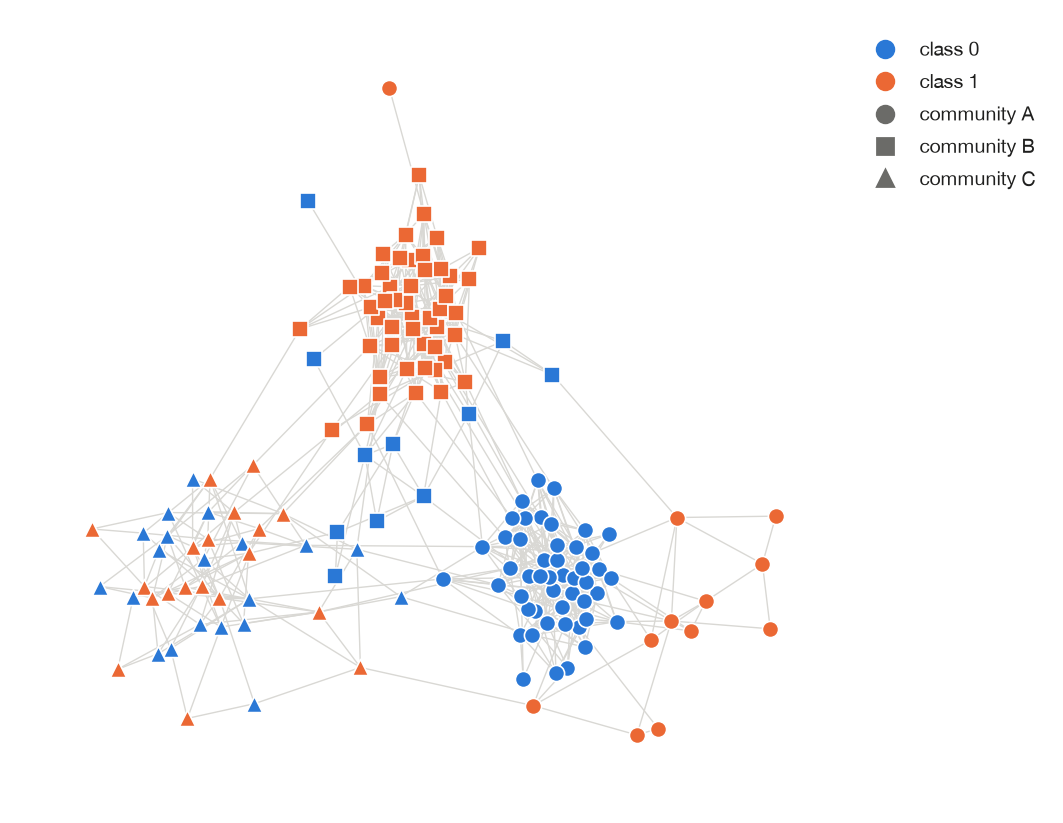

In [3]:
def legend_marker(marker, color, label):
    return plt.Line2D([], [], marker=marker, linestyle="", color=color, label=label)


positions = nx.spring_layout(graph, seed=SEED)
community_markers = {"A": "o", "B": "s", "C": "^"}

fig, ax = plt.subplots(figsize=(5.2, 4.0), layout="constrained")
nx.draw_networkx_edges(graph, positions, ax=ax, edge_color="#d9d8d4", width=0.5)
for community_name, marker in community_markers.items():
    for class_label, color in CLASS_COLORS.items():
        members = nodes.index[
            (nodes["community"] == community_name) & (nodes["label"] == class_label)
        ]
        nx.draw_networkx_nodes(
            graph,
            positions,
            nodelist=list(members),
            node_shape=marker,
            node_color=color,
            node_size=34,
            edgecolors="white",
            linewidths=0.6,
            ax=ax,
        )
handles = [legend_marker("o", color, f"class {label}") for label, color in CLASS_COLORS.items()]
handles += [
    legend_marker(marker, "#6b6b68", f"community {name}")
    for name, marker in community_markers.items()
]
ax.legend(handles=handles, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set_axis_off()

## 2. Create embeddings

Both methods see only the graph, never the attributes, and both produce 8-dimensional vectors.

- **Laplacian Eigenmaps**: the smallest non-trivial eigenvectors of the graph Laplacian, via `sklearn.manifold.SpectralEmbedding` on the adjacency matrix.
- **DeepWalk**: uniform random walks treated as sentences and embedded with `gensim` Word2Vec (skip-gram).

In [4]:
def laplacian_eigenmaps(graph, dimensions):
    adjacency = nx.to_numpy_array(graph, nodelist=list(graph.nodes))
    embedding = SpectralEmbedding(
        n_components=dimensions, affinity="precomputed", random_state=SEED
    )
    return pd.DataFrame(embedding.fit_transform(adjacency), index=list(graph.nodes))


def deepwalk(graph, dimensions, walks_per_node=20, walk_length=20):
    walk_rng = np.random.default_rng(SEED)
    walks = []
    for _ in range(walks_per_node):
        for start in graph.nodes:
            walk = [start]
            while len(walk) < walk_length:
                walk.append(walk_rng.choice(list(graph[walk[-1]])))
            walks.append([str(node) for node in walk])
    model = Word2Vec(
        walks, vector_size=dimensions, window=5, min_count=0, sg=1, workers=1, seed=SEED
    )
    return pd.DataFrame([model.wv[str(node)] for node in graph.nodes], index=list(graph.nodes))


embeddings = {
    "Laplacian Eigenmaps": laplacian_eigenmaps(graph, DIMENSIONS),
    "DeepWalk": deepwalk(graph, DIMENSIONS),
}
{name: embedding.shape for name, embedding in embeddings.items()}

{'Laplacian Eigenmaps': (158, 8), 'DeepWalk': (158, 8)}

The first two dimensions of each embedding, for illustration only:

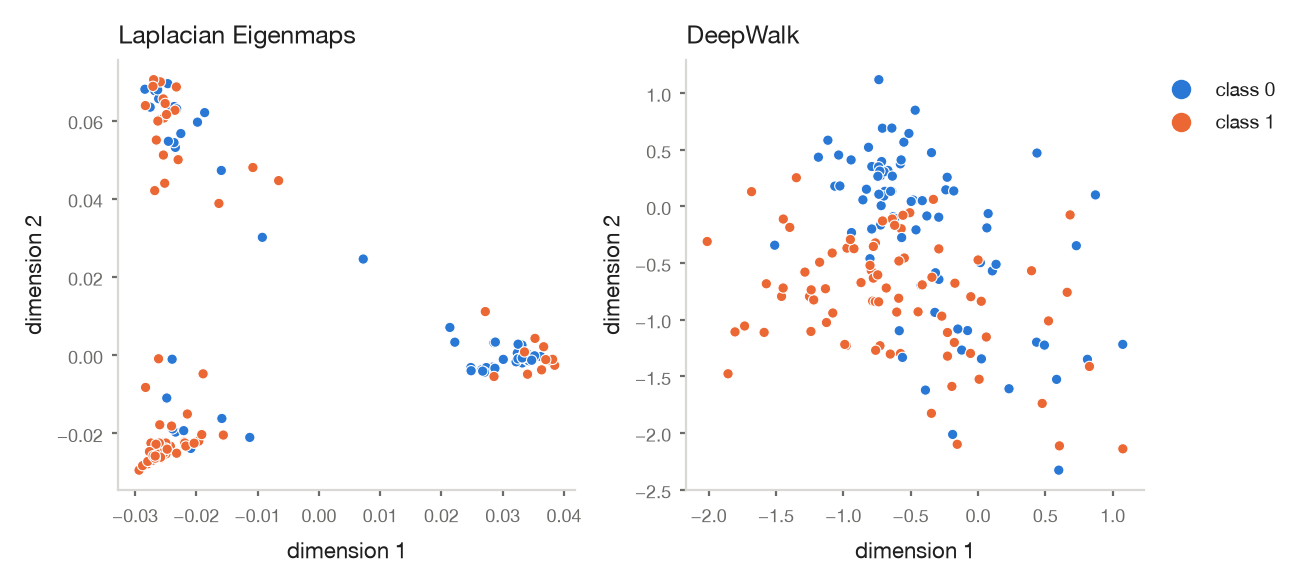

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8), layout="constrained")
for ax, (name, embedding) in zip(axes, embeddings.items(), strict=True):
    ax.scatter(
        embedding[0],
        embedding[1],
        c=nodes["label"].map(CLASS_COLORS),
        s=14,
        edgecolors="white",
        linewidths=0.4,
    )
    ax.set_title(name, loc="left")
    ax.set_xlabel("dimension 1")
    ax.set_ylabel("dimension 2")
    ax.tick_params(length=2, labelsize=6.5)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(
    handles=[legend_marker("o", color, f"class {label}") for label, color in CLASS_COLORS.items()],
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
);

## 3. Node classification

The same split, the same standardization and the same logistic regression for both embeddings.

In [6]:
train_nodes, test_nodes = train_test_split(
    nodes.index, test_size=0.3, stratify=nodes["label"], random_state=SEED
)


def classify(embedding):
    classifier = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    classifier.fit(embedding.loc[train_nodes], nodes.loc[train_nodes, "label"])
    predicted = classifier.predict(embedding.loc[test_nodes])
    observed = nodes.loc[test_nodes, "label"]
    return {
        "accuracy": accuracy_score(observed, predicted),
        "macro_f1": f1_score(observed, predicted, average="macro"),
    }


classification = pd.DataFrame(
    {name: classify(embedding) for name, embedding in embeddings.items()}
).T
classification.round(3)

,accuracy,macro_f1
Laplacian Eigenmaps,0.812,0.810
DeepWalk,0.854,0.853


On this split DeepWalk labels 41 of the 48 test nodes correctly and Laplacian Eigenmaps 39. For this task the two embeddings perform similarly: rerunning the notebook with seeds 0–19, Laplacian Eigenmaps is more accurate for 13 seeds, DeepWalk for 6, and they tie once.

## 4. Topology–attribute distortion

In [7]:
results = {
    name: tard.compute(graph, attributes, embedding, max_hops=4)
    for name, embedding in embeddings.items()
}
summary = classification.assign(
    global_distortion=[result.global_distortion for result in results.values()]
)
summary.round(3)

,accuracy,macro_f1,global_distortion
Laplacian Eigenmaps,0.812,0.810,0.327
DeepWalk,0.854,0.853,0.438


The two embeddings differ more in global distortion than in accuracy, and consistently so: DeepWalk has the higher global distortion for all 20 seeds. On average it changes how similar nodes are to the nodes around them in the graph more strongly. The matrices show where and at which distances.

## 5. Distortion maps

Both maps share one fixed color scale. The few cells beyond it are drawn in the end color, marked by the arrow on the colorbar. Rows are ordered by community, then class.

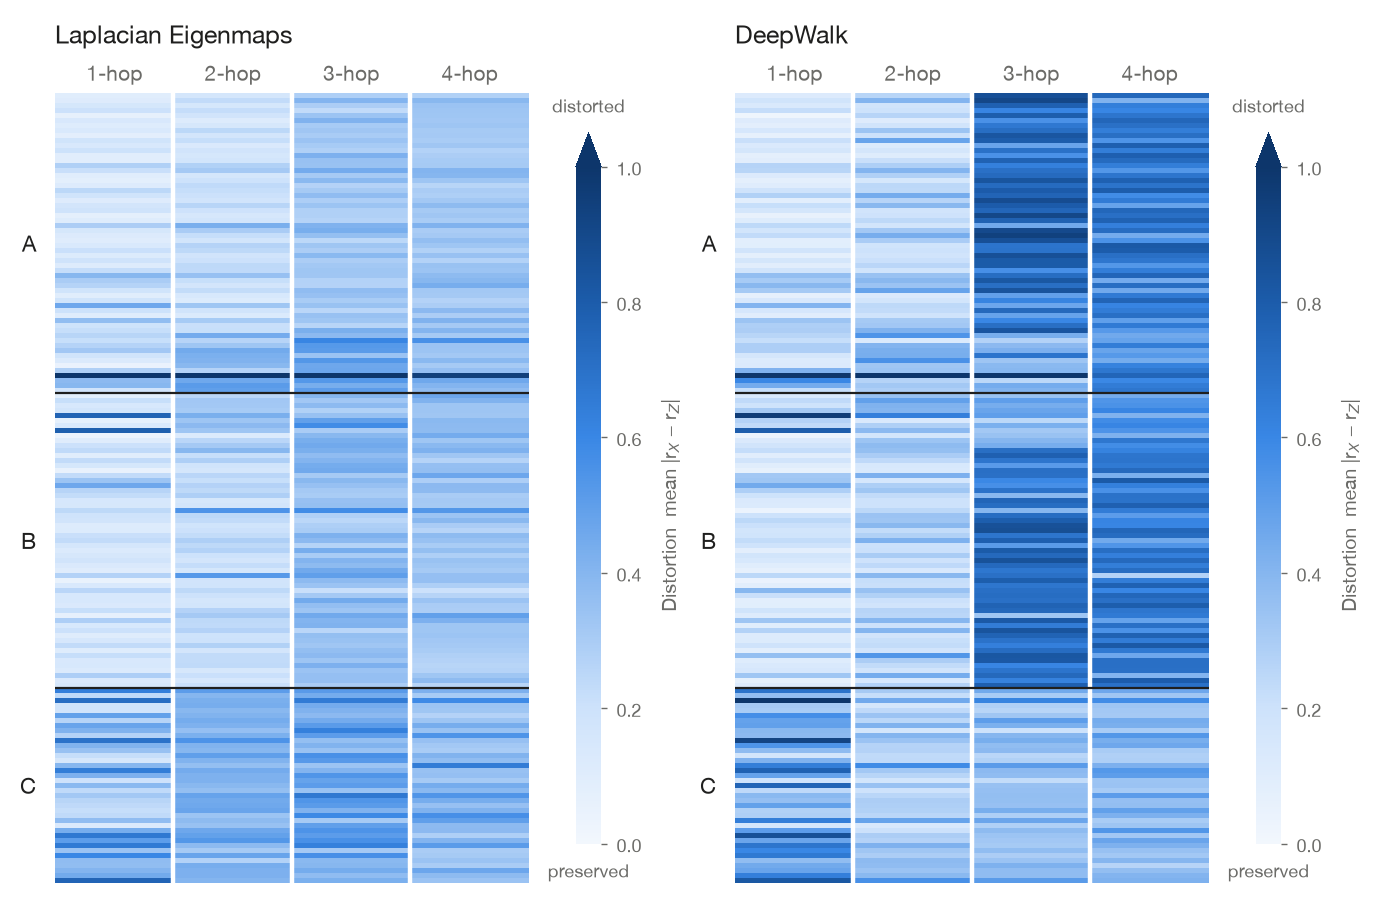

In [8]:
boundaries = (
    np.flatnonzero(nodes["community"].to_numpy()[1:] != nodes["community"].to_numpy()[:-1]) + 1
)
community_centers = (
    nodes.reset_index(drop=True)
    .groupby("community")
    .apply(lambda group: group.index.to_numpy().mean() + 0.5, include_groups=False)
)


def mark_communities(ax):
    for boundary in boundaries:
        ax.axhline(boundary, color="#1f1f1e", linewidth=0.8)
    for name, center in community_centers.items():
        ax.text(
            -0.04,
            center,
            name,
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="center",
            fontsize=8,
        )
    ax.set_ylabel("")


def compare_maps(plot, **shared_scale):
    fig, axes = plt.subplots(1, 2, figsize=(6.8, 4.4), layout="constrained")
    for ax, (name, result) in zip(axes, results.items(), strict=True):
        plot(result, ax=ax, title=name, **shared_scale)
        mark_communities(ax)


compare_maps(tard.plot_distortion_map, vmax=1.0)

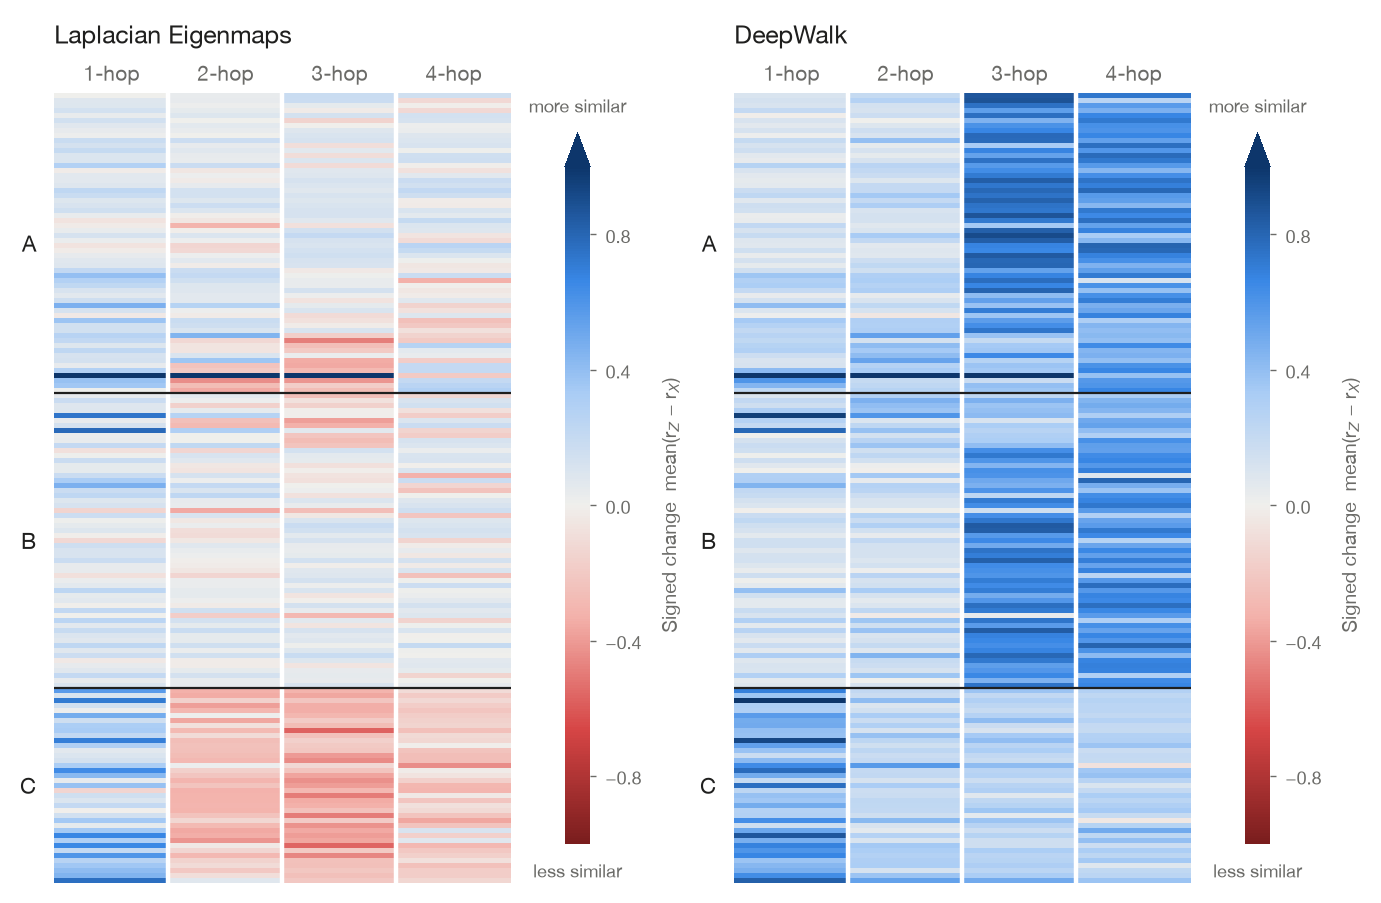

In [9]:
compare_maps(tard.plot_signed_map, limit=1.0)

- **Laplacian Eigenmaps** changes little in the homophilic communities A and B. In the heterophilic community C it pulls direct neighbours together (blue at 1 hop) and makes nodes two and three hops away less similar (red).
- **DeepWalk** also pulls direct neighbours in C together, but its largest change is at 3 and 4 hops in A and B: nodes that are far apart in the graph, and dissimilar in their attributes, become more similar.

## 6. Scale profiles

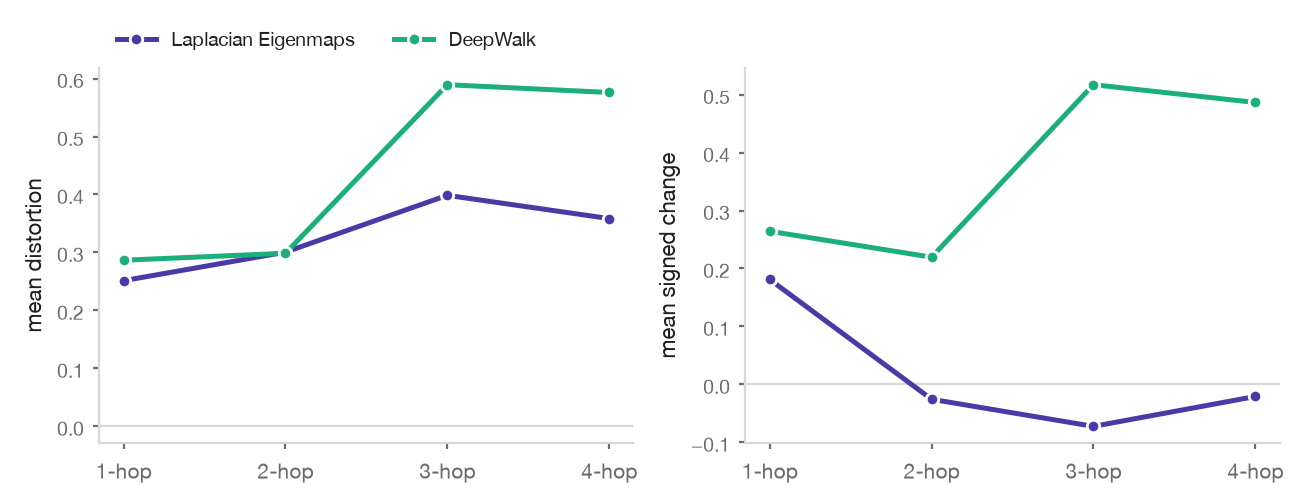

In [10]:
def plot_profiles(ax, profiles, ylabel):
    ax.axhline(0, color="#d9d8d4", linewidth=0.8, zorder=0)
    for name, profile in profiles.items():
        ax.plot(
            range(1, len(profile) + 1),
            profile.to_numpy(),
            color=METHOD_COLORS[name],
            marker="o",
            markersize=4.5,
            markeredgecolor="white",
            linewidth=1.8,
            label=name,
        )
    ax.set_xticks(range(1, len(profile) + 1), list(profile.index))
    ax.set_ylabel(ylabel)
    ax.tick_params(length=2)
    ax.spines[["top", "right"]].set_visible(False)


fig, (left, right) = plt.subplots(1, 2, figsize=(6.4, 2.4), layout="constrained")
plot_profiles(
    left, {name: result.distortion.mean() for name, result in results.items()}, "mean distortion"
)
plot_profiles(
    right,
    {name: result.signed_change.mean() for name, result in results.items()},
    "mean signed change",
)
left.legend(frameon=False, loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=2);

Averaged over nodes, both methods change 1- and 2-hop relationships by similar amounts. From 3 hops on they diverge: the mean signed change of Laplacian Eigenmaps stays near zero, while DeepWalk makes distant nodes clearly more similar. Part of this has a simple cause:

In [11]:
def mean_pairwise_cosine(vectors):
    unit = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    return (unit @ unit.T)[np.triu_indices(len(unit), k=1)].mean()


pd.Series(
    {"attributes": mean_pairwise_cosine(attributes.to_numpy())}
    | {name: mean_pairwise_cosine(embedding.to_numpy()) for name, embedding in embeddings.items()},
    name="mean cosine similarity over all node pairs",
).round(3)

attributes             0.031
Laplacian Eigenmaps    0.006
DeepWalk               0.429
Name: mean cosine similarity over all node pairs, dtype: float64

DeepWalk's vectors share a common direction, so almost any two nodes have a positive cosine similarity. A standardized linear classifier is insensitive to such a shared offset; anything that compares nodes by cosine similarity, such as nearest-neighbour retrieval or clustering, is not.

## 7. One node where the methods differ most

In [12]:
difference = (
    results["DeepWalk"].distortion.mean(axis=1)
    - results["Laplacian Eigenmaps"].distortion.mean(axis=1)
).abs()
node = difference.idxmax()
nodes.loc[[node]].assign(degree=graph.degree[node])

,community,label,degree
87,B,1,14


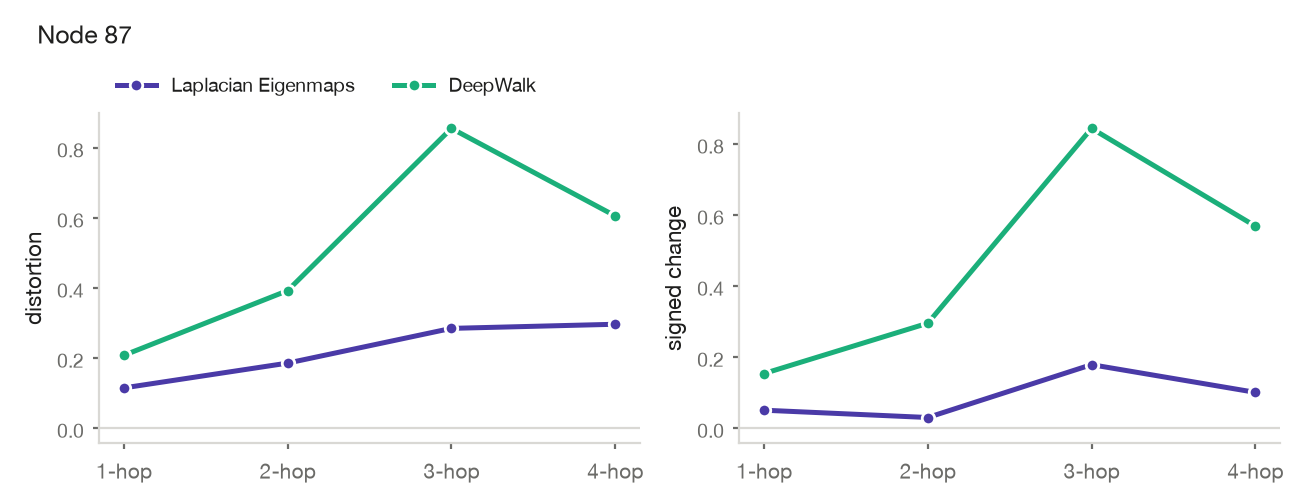

In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(6.4, 2.4), layout="constrained")
plot_profiles(
    left, {name: result.distortion.loc[node] for name, result in results.items()}, "distortion"
)
plot_profiles(
    right,
    {name: result.signed_change.loc[node] for name, result in results.items()},
    "signed change",
)
left.legend(frameon=False, loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=2)
fig.suptitle(f"Node {node}", x=0.02, ha="left", fontsize=9);

Node 87 lies in community B. Laplacian Eigenmaps changes its relationships moderately at every distance; DeepWalk makes the nodes three hops away much more similar to it than their attributes are.

## Takeaway

Classification measures whether a representation supports one particular prediction task. TARD measures how the representation changed topology–attribute relationships. These are different questions, so similar predictive performance can coexist with different distortion patterns.

Lower distortion means stronger preservation of the measured topology–attribute relationships, not a better embedding in general; whether preservation is desirable depends on what the representation is for.